# Race risk viewer

Choose a race and race hour below, then run the notebook from top to bottom. The main outputs are a per-car table at that moment and the aggregate field risk across the race.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECTS_DIR = Path("..")
SELECTED_RACE = "Daytona 2020"
VIEW_AT_HOUR = 10.0
STEP_SECONDS = 60
RETIREMENT_GRACE_SECONDS = 10 * 60

## Available races

The viewer finds timing exports in the existing race repositories under `PROJECTS_DIR`. Repositories added there later will appear automatically.

In [2]:
RACE_PATTERNS = {
    "Daytona": "**/Daytona24/data/2020_jan.csv",
    "Lime Rock": "**/NortheastGrandPrix/data/race_data/*.csv",
    "Mid-Ohio": "**/Mid-Ohio/data/race_data/*.csv",
    "Laguna Seca": "**/LagunaSeca/data/race_data/*.csv",
    "Watkins Glen": "**/Glen/data/race_data/*.csv",
    "Watkins Glen sprint": "**/Glen/sprint/data/race_data/*.csv",
    "Detroit": "**/Detroit/data/race_data/*.csv",
}
REQUIRED_COLUMNS = {"Car", "Session Time", "Flag", "Location"}


def discover_races(projects_dir):
    projects_dir = projects_dir.resolve()
    races = {}

    for circuit, pattern in RACE_PATTERNS.items():
        for path in projects_dir.glob(pattern):
            columns = set(pd.read_csv(path, nrows=0).columns)
            if not REQUIRED_COLUMNS.issubset(columns):
                continue
            year = "2020" if circuit == "Daytona" else path.stem
            races[f"{circuit} {year}"] = path.resolve()

    return dict(sorted(races.items()))


race_files = discover_races(PROJECTS_DIR)
available_races = pd.Series(
    {race: path.relative_to(PROJECTS_DIR.resolve()) for race, path in race_files.items()},
    name="file",
).rename_axis("race").to_frame()
display(available_races)

if SELECTED_RACE not in race_files:
    choices = ", ".join(race_files)
    raise ValueError(f"Unknown race {SELECTED_RACE!r}. Choose one of: {choices}")

,file
race,
Daytona 2020,Daytona24/data/2020_jan.csv
Lime Rock 2017,NortheastGrandPrix/data/race_data/2017.csv
Lime Rock 2018,NortheastGrandPrix/data/race_data/2018.csv
Lime Rock 2019,NortheastGrandPrix/data/race_data/2019.csv


## Timing data

Each source row is a car crossing the timing line. Session clocks are converted to seconds so races that pass midnight remain continuous.

In [3]:
def clock_seconds(value):
    if pd.isna(value):
        return np.nan

    parts = [float(part) for part in str(value).split(":")]
    if len(parts) > 3:
        raise ValueError(f"Unknown clock value: {value}")
    return sum(part * 60**power for power, part in enumerate(reversed(parts)))


def unwrap_session_clock(values):
    seconds = []
    day_offset = 0
    latest = 0

    for value in values:
        current = clock_seconds(value)
        if np.isnan(current):
            seconds.append(np.nan)
            continue
        current += day_offset
        if current < latest - 12 * 3600:
            day_offset += 24 * 3600
            current += 24 * 3600
        latest = max(latest, current)
        seconds.append(current)

    return seconds


source_path = race_files[SELECTED_RACE]
laps = pd.read_csv(source_path, dtype={"Car": "string"})
laps["race_seconds"] = unwrap_session_clock(laps["Session Time"])
laps = laps.dropna(subset=["Car", "race_seconds"]).sort_values("race_seconds").reset_index(drop=True)
laps["race_hour"] = laps["race_seconds"] / 3600
laps["flag"] = laps["Flag"].astype("string").str.lower().fillna("")
laps["in_pit"] = laps["Location"].astype("string").str.lower().eq("pit")

display(laps[["Car", "Driver", "Lap", "Session Time", "race_hour", "flag", "in_pit"]].head(10))
display(
    pd.Series(
        {
            "rows": len(laps),
            "cars": laps["Car"].nunique(),
            "race hours": laps["race_hour"].max(),
            "pit rows": laps["in_pit"].sum(),
            "yellow rows": laps["flag"].eq("yellow").sum(),
        },
        name="value",
    ).to_frame()
)

,Car,Driver,Lap,Session Time,race_hour,flag,in_pit
0,77,Oliver Jarvis,1,1:37.228,0.027008,green,False
1,6,Juan Pablo Montoya,1,1:38.579,0.027383,green,False
2,31,Felipe Nasr,1,1:39.156,0.027543,green,False
3,55,Jonathan Bomarito,1,1:39.389,0.027608,green,False
4,10,Ryan Briscoe,1,1:40.409,0.027891,green,False
5,85,Tristan Vautier,1,1:40.992,0.028053,green,False
6,7,Ricky Taylor,1,1:41.196,0.028110,green,False
7,5,Joao Barbosa,1,1:42.164,0.028379,green,False
8,52,Ben Keating,1,1:44.838,0.029122,green,False
9,81,Henrik Hedman,1,1:49.140,0.030317,green,False


,value
rows,27526.000000
cars,38.000000
race hours,24.036936
pit rows,1151.000000
yellow rows,1118.000000


## Observed yellow periods

Stored start/end labels are used when a race repository has them. Otherwise, yellow timing rows separated by more than three minutes are treated as different cautions.

In [4]:
def saved_caution_path(source):
    if source.parent.name != "race_data":
        return None
    candidate = source.parent.parent / source.stem / f"{source.stem[-2:]}_start_end.csv"
    return candidate if candidate.exists() else None


def caution_periods(lap_data, source):
    caution_path = saved_caution_path(source)
    if caution_path:
        periods = pd.read_csv(caution_path).rename(
            columns={"Start": "start_seconds", "End": "end_seconds"}
        )[["start_seconds", "end_seconds"]]
    else:
        yellow_times = np.sort(
            lap_data.loc[lap_data["flag"].eq("yellow"), "race_seconds"].unique()
        )
        groups = np.split(yellow_times, np.where(np.diff(yellow_times) > 180)[0] + 1) if len(yellow_times) else []
        periods = pd.DataFrame(
            [(group[0], group[-1]) for group in groups],
            columns=["start_seconds", "end_seconds"],
        )

    periods = periods.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
    periods.index += 1
    periods.index.name = "caution"
    periods["start_hour"] = periods["start_seconds"] / 3600
    periods["end_hour"] = periods["end_seconds"] / 3600
    periods["duration_minutes"] = (periods["end_seconds"] - periods["start_seconds"]) / 60
    return periods


cautions = caution_periods(laps, source_path)
cautions[["start_hour", "end_hour", "duration_minutes"]].round(2)

,start_hour,end_hour,duration_minutes
caution,,,
1,4.73,5.09,21.61
2,7.76,8.04,16.38
3,10.10,10.37,16.03
4,18.18,18.47,16.91
5,19.02,19.32,17.96
6,19.60,19.71,6.66


## Risk score

A car's score is based on minutes since its last pit stop. It combines the two curves used in the earlier race projects, centered at 0 and 38.13 minutes. This is an experimental score, not a probability or a trained prediction.

In [5]:
def normal_pdf(values, mean, std):
    values = np.asarray(values, dtype=float)
    return np.exp(-0.5 * ((values - mean) / std) ** 2) / (std * np.sqrt(2 * np.pi))


def car_risk(minutes_since_pit):
    return normal_pdf(minutes_since_pit, 0, 11.07) + normal_pdf(minutes_since_pit, 38.13, 4.65)


cars = np.sort(laps["Car"].unique())
race_grid = np.arange(0, laps["race_seconds"].max() + 1, STEP_SECONDS)
last_seen = laps.groupby("Car")["race_seconds"].max()
pit_stops = (
    laps.loc[laps["in_pit"]]
    .groupby("Car")["race_seconds"]
    .apply(lambda values: np.sort(values.unique()))
    .to_dict()
)

car_frames = []
for car in cars:
    stops = np.unique(np.insert(pit_stops.get(car, np.array([])), 0, 0))
    last_pit = stops[np.searchsorted(stops, race_grid, side="right") - 1]
    stint_age = (race_grid - last_pit) / 60
    car_frames.append(
        pd.DataFrame(
            {
                "race_seconds": race_grid,
                "race_hour": race_grid / 3600,
                "car": car,
                "active": race_grid <= last_seen[car] + RETIREMENT_GRACE_SECONDS,
                "last_pit_minute": last_pit / 60,
                "stint_age_minutes": stint_age,
                "risk_score": car_risk(stint_age),
            }
        )
    )

car_timeline = pd.concat(car_frames, ignore_index=True)
field_timeline = (
    car_timeline.loc[car_timeline["active"]]
    .groupby(["race_seconds", "race_hour"], as_index=False)
    .agg(field_risk_score=("risk_score", "sum"), active_cars=("car", "nunique"))
)

pd.Series(
    {"car timeline rows": len(car_timeline), "field timeline rows": len(field_timeline)},
    name="value",
).to_frame()

,value
car timeline rows,54834
field timeline rows,1443


## Per-car risk at the selected time

In [6]:
view_second = race_grid[np.abs(race_grid - VIEW_AT_HOUR * 3600).argmin()]
point_table = (
    car_timeline.loc[car_timeline["race_seconds"].eq(view_second)]
    .drop(columns=["race_seconds", "race_hour"])
    .sort_values(["active", "risk_score"], ascending=False)
    .set_index("car")
)

print(f"{SELECTED_RACE} at {view_second / 3600:.2f} race hours")
point_table.round(4)

Daytona 2020 at 10.00 race hours


,active,last_pit_minute,stint_age_minutes,risk_score
car,,,,
38,True,596.0236,3.9764,0.0338
5,True,593.7707,6.2293,0.0308
10,True,592.9917,7.0083,0.0295
47,True,592.1768,7.8232,0.0281
16,True,592.0752,7.9248,0.0279
31,True,591.7802,8.2198,0.0274
55,True,590.9517,9.0483,0.0258
18,True,590.7147,9.2853,0.0254
54,True,589.9871,10.0129,0.0239


## Aggregate field risk

Only active cars contribute to the field total. A car remains active until ten minutes after its last timing record so a retired car does not keep adding risk for the rest of the race.

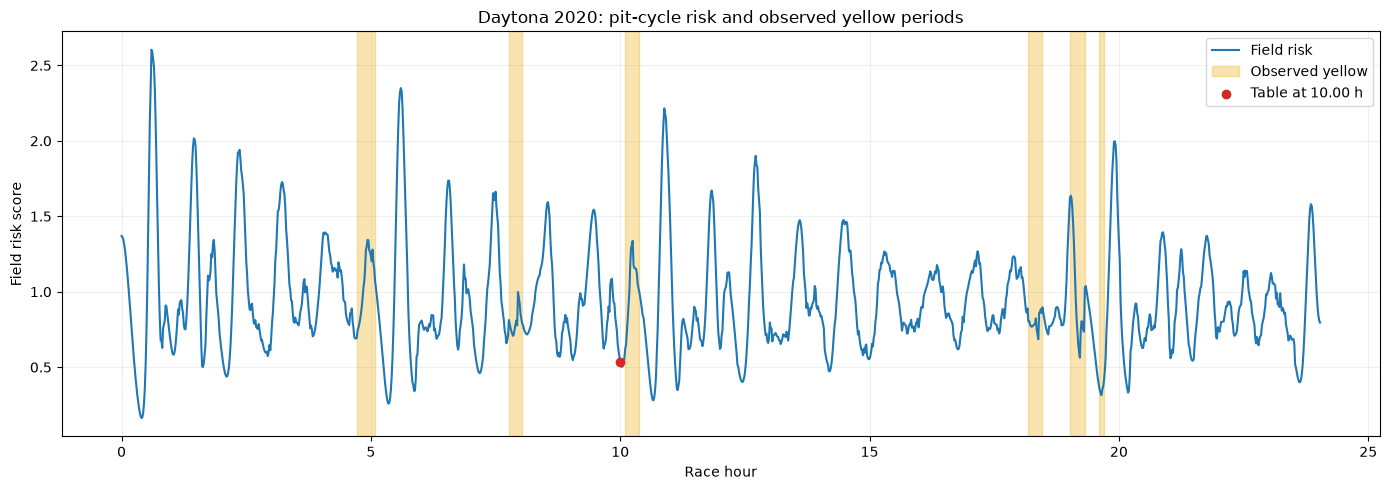

In [7]:
selected_field = field_timeline.iloc[(field_timeline["race_seconds"] - view_second).abs().argmin()]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    field_timeline["race_hour"],
    field_timeline["field_risk_score"],
    color="#1f77b4",
    label="Field risk",
)
for number, caution in enumerate(cautions.itertuples()):
    ax.axvspan(
        caution.start_hour,
        caution.end_hour,
        color="#f2c14e",
        alpha=0.45,
        label="Observed yellow" if number == 0 else None,
    )
ax.scatter(
    selected_field["race_hour"],
    selected_field["field_risk_score"],
    color="#d62728",
    zorder=3,
    label=f"Table at {selected_field['race_hour']:.2f} h",
)
ax.set(
    title=f"{SELECTED_RACE}: pit-cycle risk and observed yellow periods",
    xlabel="Race hour",
    ylabel="Field risk score",
)
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()